# Task
Fine tune a roBERTa model

In [1]:
#!pip install jupyter_contrib_nbextensions
#!jupyter contrib nbextension install --user
#!jupyter nbextension enable varInspector/main

In [2]:
#!pip install ipywidgets
#!jupyter nbextension enable --py widgetsnbextension
#!pip install accelerate -U
#!pip install -q transformers datasets evaluate scikit-learn accelerate
#!pip install --upgrade ipywidgets
#!jupyter nbextension enable --py widgetsnbextension --sys-prefix
#!jupyter nbextension install --py widgetsnbextension --sys-prefix

## Dataprocess

In [3]:
import json
from datasets import Dataset
from typing import List, Dict

C:\Users\abedh\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
def load_raw_data(path: str) -> List[Dict]:
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


In [5]:
INSTRUCTION = (
    """
    You are an expert enterprise support triage system.
    TASK:
    Identify which technical component is most likely responsible for the issue."""
)
def build_input_text(
    workflow_desc: str,
    component_name: str,
    component_desc: str,
    complaint: str
) -> str:
    return (
        f"Instruction:\n{INSTRUCTION}\n"
        f"Workflow:\n{workflow_desc}\n\n"
        f"Component:\n"
        f"Name: {component_name}\n"
        f"Description: {component_desc}\n\n"
        f"User complaint:\n{complaint}\n\n"
        f"Answer:"
    )

def explode_example(example):
    workflow = example["workflow"]
    complaint = example["user_complaint"]["user_complaint"]

    workflow_desc = (
        f"{workflow['workflow_name']}. "
        f"{workflow['workflow_description']}"
    )

    true_component = example["malfunction"]["affected_component"]["name"]

    rows = []

    for component in workflow["workflow_components"]:
        label = int(component["name"] == true_component)

        input_text = build_input_text(
            workflow_desc=workflow_desc,
            component_name=component["name"],
            component_desc=component["description"],
            complaint=complaint
        )

        rows.append({
            "input_text": input_text,
            "label": label,
            "example_id": example["example_id"],
            "component_name": component["name"],
            "workflow_name": workflow["workflow_name"]
        })

    return rows

def build_flat_dataset(raw_data):
    all_rows = []

    for example in raw_data:
        all_rows.extend(explode_example(example))

    return Dataset.from_list(all_rows)



In [6]:
from sklearn.model_selection import train_test_split
def split_by_workflow(dataset, test_size=0.2, seed=42):
    workflows = list(set(dataset["workflow_name"]))

    train_wf, test_wf = train_test_split(
        workflows, test_size=test_size, random_state=seed
    )

    train_ds = dataset.filter(lambda x: x["workflow_name"] in train_wf)
    test_ds = dataset.filter(lambda x: x["workflow_name"] in test_wf)

    return train_ds, test_ds


## Tokenization

In [7]:
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
tokenizer = RobertaTokenizerFast.from_pretrained(
    "roberta-base")
def tokenize(batch):
    return tokenizer(
        batch["input_text"],
        padding="max_length",
        truncation=True,
        max_length=384
    )


In [8]:
def tokenize_dataset(dataset):
    dataset = dataset.map(tokenize, batched=True)
    dataset = dataset.remove_columns(
        ["input_text", "component_name", "workflow_name"]
    )
    dataset.set_format("torch")
    return dataset


# class imbalance

In [9]:
import torch
def compute_class_weights(dataset):
    labels = torch.tensor(dataset["label"])
    pos = labels.sum().item()
    neg = len(labels) - pos

    weight_for_0 = 1.0
    weight_for_1 = neg / max(pos, 1)

    return torch.tensor([weight_for_0, weight_for_1])


# Pipeline

In [10]:
def preprocess_pipeline(path):
    raw_data = load_raw_data(path)
    flat_ds = build_flat_dataset(raw_data)

    train_ds, test_ds = split_by_workflow(flat_ds)

    train_ds = tokenize_dataset(train_ds)
    test_ds = tokenize_dataset(test_ds)

    class_weights = compute_class_weights(train_ds)

    return train_ds, test_ds, class_weights


In [11]:
train_ds, test_ds, class_weights = preprocess_pipeline(
    "2190_dataset.json"
)

Map: 100%|████████████████████████████████████████████████████████████████| 2725/2725 [00:00<00:00, 3753.41 examples/s]


In [12]:
train_ds = train_ds.remove_columns(["example_id"])
test_ds = test_ds.remove_columns(["example_id"])

In [13]:
import torch
print("PyTorch version:", torch.version)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

PyTorch version: <module 'torch.version' from 'C:\\Users\\abedh\\AppData\\Local\\Programs\\Python\\Python310\\lib\\site-packages\\torch\\version.py'>
CUDA available: True
GPU name: NVIDIA GeForce RTX 4070 Laptop GPU


## Train

In [14]:
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2
)

from transformers import Trainer
import torch
import torch.nn as nn

class WeightedTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
        )
        loss = loss_fct(logits, labels)

        return (loss, outputs) if return_outputs else loss



Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
import torch


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Moving model to: {device}")

model.to(device)

if isinstance(class_weights, torch.Tensor):
    class_weights = class_weights.to(device)

Moving model to: cuda


In [16]:
from transformers import TrainingArguments
from transformers import EarlyStoppingCallback

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,
    weight_decay=0.01,

    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",

    report_to="none",
    fp16=torch.cuda.is_available()
)
from sklearn.metrics import accuracy_score, f1_score
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print(trainer.model.device)
trainer.train()
trainer.evaluate()

trainer.save_model("./roberta-model")

# בדיקת distribution של logits
outputs = trainer.predict(test_ds)
logits = outputs.predictions

print("Logits sample:", logits[:3])

# בדיקת false positives
preds = logits.argmax(axis=-1)
labels = outputs.label_ids

fp_idx = (preds == 1) & (labels == 0)
print("False positives:", fp_idx.sum())



cuda:0


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.370900,0.275661,0.935046,0.840684
2,0.282000,0.212359,0.942018,0.866102
3,0.197200,0.306223,0.954495,0.886447


Logits sample: [[ 0.12878418 -0.6323242 ]
 [-2.4179688   2.0644531 ]
 [ 2.6679688  -3.1269531 ]]
False positives: 124


## Inference

In [17]:
import torch
import torch.nn.functional as F

def predict_root_cause(
    model,
    tokenizer,
    workflow: dict,
    complaint: str,
    top_k=1
):
    workflow_desc = (
        f"{workflow['workflow_name']}. "
        f"{workflow['workflow_description']}"
    )

    scores = []

    for component in workflow["workflow_components"]:
        score = score_component(
            model=model,
            tokenizer=tokenizer,
            workflow_desc=workflow_desc,
            component_name=component["name"],
            component_desc=component["description"],
            complaint=complaint
        )

        scores.append({
            "component": component["name"],
            "score": score
        })

    scores = sorted(scores, key=lambda x: x["score"], reverse=True)
    return scores[:top_k]


## Tests on the model

In [18]:
tokenizer.save_pretrained("./roberta-model")

('./roberta-model\\tokenizer_config.json',
 './roberta-model\\special_tokens_map.json',
 './roberta-model\\vocab.json',
 './roberta-model\\merges.txt',
 './roberta-model\\added_tokens.json',
 './roberta-model\\tokenizer.json')

In [19]:
import json
import torch
import torch.nn.functional as F

from tqdm import tqdm
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_PATH = "./roberta-model"  #change name



tokenizer = RobertaTokenizerFast.from_pretrained(MODEL_PATH)
model = RobertaForSequenceClassification.from_pretrained(MODEL_PATH)
model.to(DEVICE)
model.eval()

def score_component(
    workflow_desc: str,
    component_name: str,
    component_desc: str,
    complaint: str,
    max_length=384
) -> float:

    input_text = build_input_text(
        workflow_desc=workflow_desc,
        component_name=component_name,
        component_desc=component_desc,
        complaint=complaint
    )

    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )

    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        probs = F.softmax(outputs.logits, dim=-1)

    # P(component is root cause)
    return probs[0, 1].item()


In [20]:
def infer_example(example, top_k=3):
    workflow = example["workflow"]
    complaint = example["user_complaint"]["user_complaint"]

    workflow_desc = (
        f"{workflow['workflow_name']}. "
        f"{workflow['workflow_description']}"
    )

    scores = []

    for component in workflow["workflow_components"]:
        score = score_component(
            workflow_desc=workflow_desc,
            component_name=component["name"],
            component_desc=component["description"],
            complaint=complaint
        )

        scores.append({
            "component_name": component["name"],
            "score": score
        })

    scores = sorted(scores, key=lambda x: x["score"], reverse=True)

    return {
        "example_id": example.get("example_id"),
        "predicted_root_cause": scores[0]["component_name"],
        "top_k_predictions": scores[:top_k]
    }


In [21]:
def run_inference(test_path, output_path, top_k=2):
    with open(test_path, "r", encoding="utf-8") as f:
        test_data = json.load(f)

    results = []

    for example in tqdm(test_data, desc="Running inference"):
        prediction = infer_example(example, top_k=top_k)


        if "malfunction" in example:
            prediction["ground_truth"] = example["malfunction"]["affected_component"]["name"]

        results.append(prediction)

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2, ensure_ascii=False)

    print(f"Inference results saved to: {output_path}")

In [23]:
run_inference(
    test_path="test_easy.json",
    output_path="test_predictions_easy.json"
)

Running inference: 100%|█████████████████████████████████████████████████████████████| 200/200 [00:18<00:00, 10.65it/s]

Inference results saved to: test_predictions_easy.json


In [24]:
import json
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def evaluate_predictions(results_path):
    print(f"--- Loading results from: {results_path} ---")

    with open(results_path, "r", encoding="utf-8") as f:
        results = json.load(f)

    y_true = []
    y_pred = []
    top_2_hits = 0
    valid_count = 0

    for item in results:
        if "ground_truth" not in item:
            continue

        gt = item["ground_truth"]
        pred = item["predicted_root_cause"]

        y_true.append(gt)
        y_pred.append(pred)
        valid_count += 1


        top_2_names = [cand["component_name"] for cand in item["top_k_predictions"][:2]]

        if gt in top_2_names:
            top_2_hits += 1

    if valid_count == 0:
        print("No ground truth labels found.")
        return

    # חישובים
    acc = accuracy_score(y_true, y_pred)
    top_2_acc = top_2_hits / valid_count # חישוב לפי ה-hits של הטופ 2

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    # פלט
    print("\n" + "="*35)
    print("      EVALUATION REPORT       ")
    print("="*35)
    print(f"Total Examples:           {valid_count}")
    print(f"Top-1 Accuracy (Exact):   {acc:.2%}")
    print(f"Top-2 Accuracy:           {top_2_acc:.2%}") # תמיד ידפיס Top-2
    print("-" * 35)
    print(f"F1 Score (weighted):      {f1:.4f}")
    print("="*35)

In [25]:
evaluate_predictions("test_predictions_easy.json")

--- Loading results from: test_predictions_easy.json ---

      EVALUATION REPORT       
Total Examples:           200
Top-1 Accuracy (Exact):   88.50%
Top-2 Accuracy:           96.50%
-----------------------------------
F1 Score (weighted):      0.8785


C:\Users\abedh\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\abedh\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
C:\Users\abedh\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\a

In [26]:
run_inference(
    test_path="test_hard.json",
    output_path="test_predictions_hard.json"
)

Running inference: 100%|█████████████████████████████████████████████████████████████| 200/200 [00:19<00:00, 10.38it/s]

Inference results saved to: test_predictions_hard.json


In [27]:
evaluate_predictions("test_predictions_hard.json")

--- Loading results from: test_predictions_hard.json ---

      EVALUATION REPORT       
Total Examples:           200
Top-1 Accuracy (Exact):   95.50%
Top-2 Accuracy:           98.00%
-----------------------------------
F1 Score (weighted):      0.9542


In [28]:
def compute_top_k_accuracy(results, k):
    hits = 0
    total = 0

    for item in results:
        if "ground_truth" not in item:
            continue

        gt = item["ground_truth"]
        top_k_preds = [c["component_name"] for c in item["top_k_predictions"][:k]]

        if gt in top_k_preds:
            hits += 1
        total += 1

    return hits / total if total > 0 else 0

In [29]:
results_path= "test_predictions_hard.json"
with open(results_path, "r", encoding="utf-8") as f:
        results = json.load(f)
top1 = compute_top_k_accuracy(results, k=1)
top2 = compute_top_k_accuracy(results, k=2)

print(top1, top2)

0.955 0.98


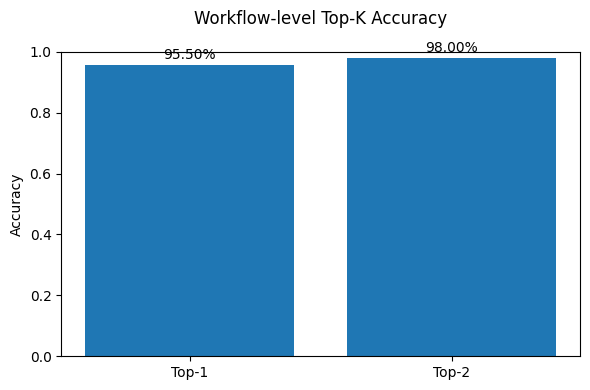

In [30]:
import matplotlib.pyplot as plt

top_k_values = {
    "Top-1": top1,
    "Top-2": top2,
}

plt.figure(figsize=(6,4))
plt.bar(top_k_values.keys(), top_k_values.values())

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Workflow-level Top-K Accuracy",pad=20)

for i, v in enumerate(top_k_values.values()):
    plt.text(i, v + 0.02, f"{v:.2%}", ha="center")

plt.tight_layout()
plt.show()